# Figures 6 and 7 — Quantitative evaluation against QR-FTLE

This notebook reproduces the manuscript's **quantitative performance analysis** for the predictive and geometry-guided FTLE proxies, corresponding to **Fig. 6** and **Fig. 7**.

Unlike the earlier notebooks, which focus on the construction of the ML-FTLE and Poincaré-FTLE proxies themselves, the purpose here is strictly **out-of-target evaluation**. Every proxy is assessed against the analytical ground-truth QR-FTLE trajectory $\lambda_{\mathrm{QR}}$, which remains completely excluded from the PLSR calibration step.

This distinction is central to the manuscript: the geometric proxy $\hat{\lambda}_{\mathrm{geo}}^{(m)}$ is trained only against the empirical ML-FTLE target $\hat{\lambda}_{\mathrm{ML}}$, while QR-FTLE is used here solely as an independent benchmark for final validation.

---

## Evaluation goals

The notebook computes the two principal manuscript metrics for each dataset $\mathcal{D}_k$ and for each estimator family:

| Metric                                 | Manuscript role                                                                                   |
| -------------------------------------- | ------------------------------------------------------------------------------------------------- |
| Spearman rank correlation $\rho$       | Measures continuous monotonic agreement with $\lambda_{\mathrm{QR}}$ across the full trajectory   |
| Matthews Correlation Coefficient (MCC) | Measures binary chaotic/non-chaotic classification fidelity relative to the instability threshold |

A supplementary **Sign Agreement** score is also reported as a simple diagnostic of threshold-side consistency.

---

## Execution order

| Cell block  | Purpose                                                          |
| ----------- | ---------------------------------------------------------------- |
| `c01`–`c04` | Imports, parameter discovery, core functions, metric helpers     |
| `c05`       | Core computation and QR-referenced metric evaluation             |
| `c06`–`c07` | Plotting and summary cells; safe to re-run without recomputation |


### `c01_imports` — Scientific plotting and analysis imports

Loads the numerical, plotting, and statistical utilities required for the analysis.


In [17]:
from __future__ import annotations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.metrics import matthews_corrcoef
print('Imports OK')


Imports OK


### `c02_params` — Auto-discover all parameter sets

Discovers every dataset configuration defined in `parameters/data_N.py` and extracts the shared hyperparameters used by the pipeline.


In [18]:
from parameters import discover_all_params

EPS = 1e-12
PARAM_SETS = discover_all_params()
DATASETS   = [P.OUT_DIR for P in PARAM_SETS.values()]

print(f'Datasets ({len(DATASETS)}):')
for _did, _P in PARAM_SETS.items():
    _ml  = _P.OUT_DIR / 'ml_ftle.csv'
    _qr  = _P.OUT_DIR / 'qr_ftle.csv'
    _n   = len(list((_P.OUT_DIR/'csv_mkg').glob('*.csv'))) if (_P.OUT_DIR/'csv_mkg').exists() else 0
    print(f'  {_did:20s}  csv_mkg:{_n}'
          f'  ml:{"✓" if _ml.exists() else "✗"}'
          f'  qr:{"✓" if _qr.exists() else "✗ MISSING"}')

if PARAM_SETS:
    _P0 = next(iter(PARAM_SETS.values()))
    WINDOW        = _P0.T_WINDOW_STEPS
    STEP          = _P0.T_STEP
    BINS          = _P0.BINS
    METHODS       = _P0.POINCARE_METHODS
    LLE_THRESH    = _P0.LLE_THRESH
    NN            = _P0.NN_POINCARE
    METHOD_COLORS = _P0.METHOD_COLORS
    GRID_ALPHA    = _P0.GRID_ALPHA
    DPI_PLOT      = _P0.DPI_PLOT
    DPI_COMPOSITE = _P0.DPI_COMPOSITE
    LINE_WIDTH    = _P0.LINE_WIDTH
    COLORS_REP    = _P0.COLORS_REP
    print(f'WINDOW={WINDOW} STEP={STEP} BINS={BINS} LLE_THRESH={LLE_THRESH}')
    print(f'METHODS={METHODS}')


Discovered 3 parameter file(s) in d:\NLD_PROJECT\ML_FTLE\publication code\parameters:
  ✓  data_1.py  →  OUT_DIR=d:\NLD_PROJECT\ML_FTLE\publication code\data\data_1
  ✓  data_2.py  →  OUT_DIR=d:\NLD_PROJECT\ML_FTLE\publication code\data\data_2
  ✓  data_3.py  →  OUT_DIR=d:\NLD_PROJECT\ML_FTLE\publication code\data\data_3
Datasets (3):
  data_1                csv_mkg:1  ml:✓  qr:✓
  data_2                csv_mkg:1  ml:✓  qr:✓
  data_3                csv_mkg:1  ml:✓  qr:✓
WINDOW=500 STEP=30 BINS=20 LLE_THRESH=0.005
METHODS=['JSD', 'SSIM', 'HDF', 'IOU']


### `c03_core` — Import the Poincaré-FTLE core functions

Imports the helper functions from `core/poincare_ftle.py` that implement the manuscript's geometry-guided pipeline.


In [19]:
from core.poincare_ftle import (
    run_phase1_2,
    load_ftle,
    guided_pca_proxy,
    run_phase3_plsr,
)
print('core.poincare_ftle imported OK')


core.poincare_ftle imported OK


### `c04_metrics` — Metric helper and QR-FTLE loader

Defines the utility functions used to load the analytical QR-FTLE reference and to align every proxy time series onto the QR time base before evaluation.

This alignment step is essential because the ML-FTLE and PLSR-derived geometric proxies are produced on sliding-window centers, whereas the QR-FTLE reference may be sampled on a different grid. All reported metrics are therefore computed only on the temporally aligned overlap.

The cell implements three evaluation quantities:

- **Spearman rank correlation** for monotonic continuous tracking,
- **Matthews Correlation Coefficient (MCC)** for threshold-based chaotic/non-chaotic classification, and
- **Sign Agreement** as a lightweight diagnostic of qualitative regime consistency.


In [20]:


def load_qr_ftle(path):
    df    = pd.read_csv(path)
    t_col = "time" if "time" in df.columns else df.columns[0]
    l_col = ("lam1_qr_smooth" if "lam1_qr_smooth" in df.columns
             else "lam1_qr"   if "lam1_qr"        in df.columns
             else df.columns[1])
    print(f"    QR column used: '{l_col}'")
    t   = df[t_col].values.astype(float)
    lam = df[l_col].values.astype(float)
    ok  = np.isfinite(lam)
    if (~ok).sum():
        print(f"    Dropped {(~ok).sum()} NaN rows")
    return t[ok], lam[ok]


def _align_to_qr(pred_t, pred_v, t_qr, lam_qr):
    pred_on_qr = np.interp(t_qr, pred_t, pred_v, left=np.nan, right=np.nan)
    mask = np.isfinite(pred_on_qr) & np.isfinite(lam_qr)
    return pred_on_qr[mask], lam_qr[mask], mask


def compute_metrics(pred_t, pred_v, t_qr, lam_qr, thresh):
    pred_aln, qr_aln, mask = _align_to_qr(pred_t, pred_v, t_qr, lam_qr)
    n = int(mask.sum())
    if n < 5:
        return dict(spearman_rho=np.nan, mcc=np.nan, sign_agree=np.nan, n_valid=n)
    rho, _ = spearmanr(pred_aln, qr_aln)
    y_true = (qr_aln   > thresh).astype(int)
    y_pred = (pred_aln > thresh).astype(int)
    try:
        mcc = float(matthews_corrcoef(y_true, y_pred))
    except Exception:
        mcc = np.nan
    sign_agree = float(np.mean(np.sign(pred_aln) == np.sign(qr_aln)))
    return dict(spearman_rho=float(rho), mcc=mcc,
                sign_agree=sign_agree, n_valid=n)

print('load_qr_ftle() + compute_metrics() defined.')

load_qr_ftle() + compute_metrics() defined.


### `c05_compute` — Quantitative evaluation for every dataset _(run once per session)_

This is the main computation stage for the manuscript's **Quantitative Performance** subsection.

For each dataset, the code:

1. loads the analytical QR-FTLE reference from `qr_ftle.csv`,
2. loads the previously computed ML-FTLE proxy from `ml_ftle.csv`,
3. rebuilds the Poincaré-FTLE fits through the three-phase geometry-guided pipeline,
4. evaluates the ML-FTLE baseline against QR-FTLE, and
5. evaluates each geometric proxy $\hat{\lambda}_{\mathrm{geo}}^{(m)}$ against the same QR reference using identical metrics.

The resulting objects are cached in:

- `all_fit` for the fitted proxy trajectories,
- `all_metrics` for the final scalar performance metrics, and
- `qr_refs` for the aligned analytical reference series.

This cell establishes the evidence used in Figs. 6 and 7 to compare the predictive ML-FTLE and four metric-specific geometric proxies $m \in \{\mathrm{JSD}, \mathrm{SSIM}, \mathrm{HDF}, \mathrm{IOU}\}$.


In [21]:

all_fit     = {}   # dataset → method → fit dict
all_metrics = {}   # dataset → signal → metric dict
qr_refs     = {}   # dataset → (t_qr, lam_qr)

for dset in DATASETS:
    print(f"\n{'='*65}\n  Dataset: {dset.name}\n{'='*65}")
    _P = PARAM_SETS.get(dset.name, next(iter(PARAM_SETS.values())))
    WINDOW=_P.T_WINDOW_STEPS; STEP=_P.T_STEP; BINS=_P.BINS
    METHODS=_P.POINCARE_METHODS; LLE_THRESH=_P.LLE_THRESH
    NN=_P.NN_POINCARE; METHOD_COLORS=_P.METHOD_COLORS
    GRID_ALPHA=_P.GRID_ALPHA; DPI_PLOT=_P.DPI_PLOT
    DPI_COMPOSITE=_P.DPI_COMPOSITE; LINE_WIDTH=_P.LINE_WIDTH

    qr_csv = dset / 'qr_ftle.csv'
    if not qr_csv.exists():
        print('  qr_ftle.csv MISSING — skip'); continue
    t_qr, lam_qr = load_qr_ftle(qr_csv)
    qr_refs[dset.name] = (t_qr, lam_qr)
    print(f'  QR-FTLE (lam1_qr_smooth): {len(t_qr)} pts  '
      f'[{lam_qr.min():.4f}, {lam_qr.max():.4f}]')

    ml_csv = dset / 'ml_ftle.csv'
    if not ml_csv.exists():
        print('  ml_ftle.csv MISSING — skip'); continue
    t_ml, lam_ml = load_ftle(ml_csv)
    print(f'  ML-FTLE : {len(t_ml)} pts  [{lam_ml.min():.4f}, {lam_ml.max():.4f}]')

    frames, recalc = run_phase1_2(dset, _P)
    if frames is None:
        print('  Phase 1+2 failed — skip'); continue

    fit = run_phase3_plsr(dset, recalc, t_ml, lam_ml, n_components=1)

    # Attach QR refs + metrics into fit dict for plotting
    m_ml = compute_metrics(t_ml, lam_ml, t_qr, lam_qr, LLE_THRESH)
    ds_metrics = {'ML-FTLE': m_ml}

    print(f'  {"Signal":14s}  {"ρ":>7s}  {"MCC":>7s}  {"SA":>7s}  {"n":>6s}')
    print(f'  {"-"*14}  {"-"*7}  {"-"*7}  {"-"*7}  {"-"*6}')
    print(f'  {"ML-FTLE":14s}  {m_ml["spearman_rho"]:7.3f}  {m_ml["mcc"]:7.3f}'
          f'  {m_ml["sign_agree"]:7.3f}  {m_ml["n_valid"]:6d}')
    for method, res in fit.items():
        res['t_qr']   = t_qr
        res['lam_qr'] = lam_qr
        m = compute_metrics(res['t_ftle'], res['pred'], t_qr, lam_qr, LLE_THRESH)
        res['metrics_vs_qr'] = m
        ds_metrics[method] = m
        print(f'  {method:14s}  {m["spearman_rho"]:7.3f}  {m["mcc"]:7.3f}'
              f'  {m["sign_agree"]:7.3f}  {m["n_valid"]:6d}')

    all_fit[dset.name]     = fit
    all_metrics[dset.name] = ds_metrics

print('\n✓ Computation complete. Run plot cells (c07–c11) to generate figures.')



  Dataset: data_1
    QR column used: 'lam1_qr_smooth'
  QR-FTLE (lam1_qr_smooth): 189 pts  [-0.0015, 0.0301]
  ML-FTLE : 184 pts  [-0.0018, 0.0286]
  [JSD] ode_trajectory: 6 reps, base=0.8087
  [SSIM] ode_trajectory: 6 reps, base=0.4854
  [HDF] ode_trajectory: 6 reps, base=8.062
  [IOU] ode_trajectory: 6 reps, base=0.816
  Signal                ρ      MCC       SA       n
  --------------  -------  -------  -------  ------
  ML-FTLE           0.814    0.956    0.984     183
  JSD               0.912    0.933    0.738     183
  SSIM              0.943    0.955    0.809     183
  HDF               0.844    0.944    0.672     183
  IOU               0.944    0.911    0.612     183

  Dataset: data_2
    QR column used: 'lam1_qr_smooth'
  QR-FTLE (lam1_qr_smooth): 56 pts  [-0.1560, 0.0867]
  ML-FTLE : 113 pts  [-0.0017, 0.0309]
  [JSD] ode_trajectory: 10 reps, base=0.7883
  [SSIM] ode_trajectory: 10 reps, base=0.4668
  [HDF] ode_trajectory: 10 reps, base=6.403
  [IOU] ode_trajectory: 10 

### `c06_plot_all_methods` — All-method overlay against QR-FTLE

Generates a dataset-wise overlay figure showing the analytical QR-FTLE ground truth, the ML-FTLE baseline, all geometric PLSR reconstructions, and their corresponding latent variables.

Although this composite is not the final publication bar chart, it is useful during manuscript preparation because it provides a direct visual audit of how each proxy family tracks the QR reference before the comparison is compressed into the summary metrics shown in Figs. 6 and 7.


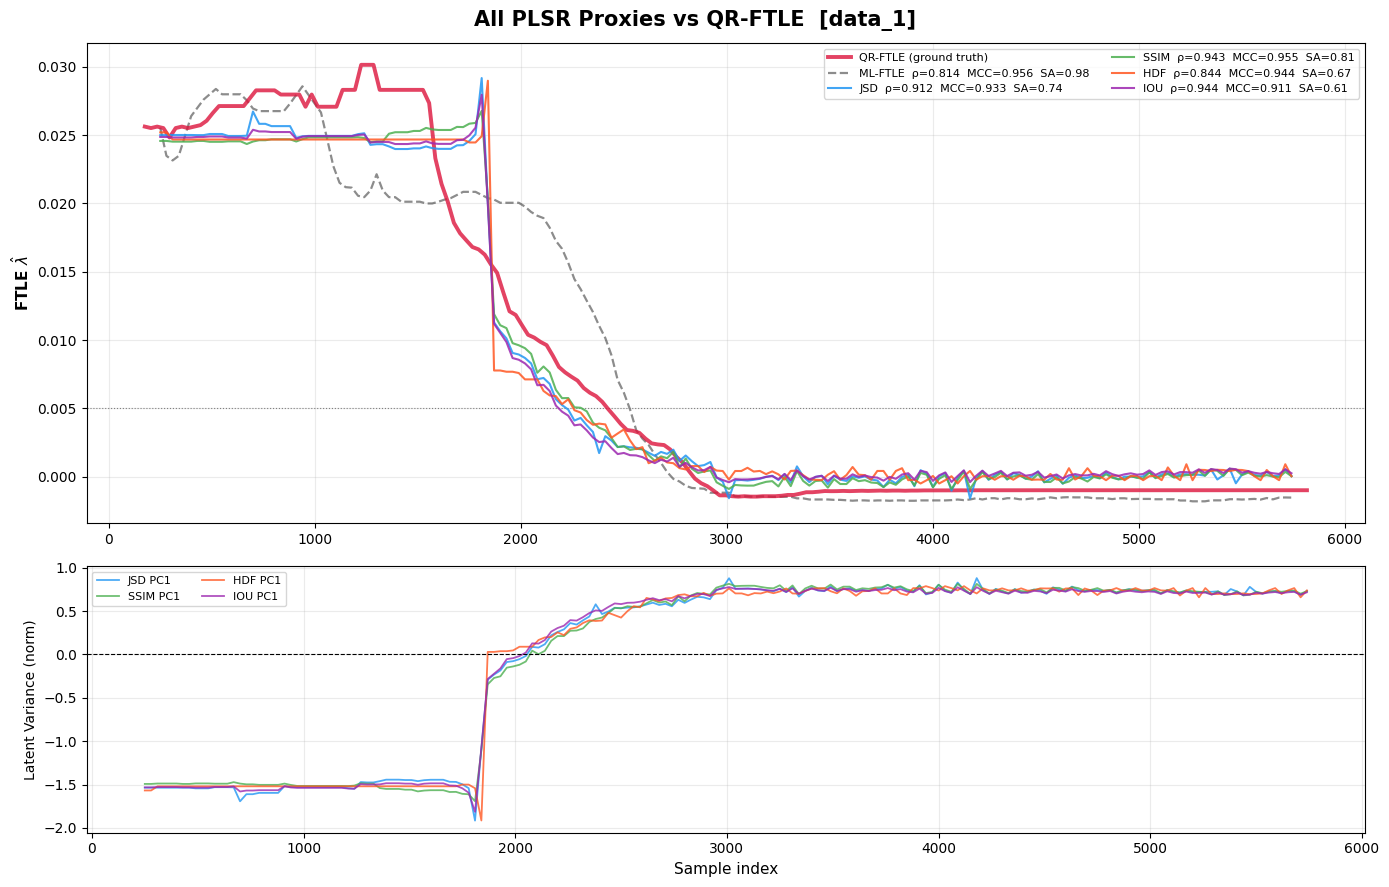

  Saved plsr_all_methods_vs_qr_ftle.png

✓ All-methods overlay plots done.


In [14]:

for ds_name, fit in all_fit.items():
    _P      = PARAM_SETS.get(ds_name, next(iter(PARAM_SETS.values())))
    fig_dir = _P.OUT_DIR / 'Figure'
    t_qr, lam_qr = qr_refs[ds_name]
    first  = list(fit.keys())[0]
    t_ml   = fit[first]['t_ftle']
    lam_ml = fit[first]['lam_ml']
    m_ml   = all_metrics[ds_name]['ML-FTLE']

    fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                              gridspec_kw={'height_ratios': [1.8, 1]},
                              sharex=False)
    fig.suptitle(f'All PLSR Proxies vs QR-FTLE  [{ds_name}]',
                 fontsize=15, fontweight='bold')

    ax = axes[0]
    ax.plot(t_qr, lam_qr, color='crimson', lw=2.8, alpha=0.8,
            label='QR-FTLE (ground truth)', zorder=3)
    ax.plot(t_ml, lam_ml, color='black', lw=1.6, alpha=0.45, ls='--',
            label=f'ML-FTLE  ρ={m_ml["spearman_rho"]:.3f}  '
                  f'MCC={m_ml["mcc"]:.3f}  SA={m_ml["sign_agree"]:.2f}',
            zorder=2)
    for method, res in fit.items():
        col  = _P.METHOD_COLORS.get(method, '#888')
        m_pr = res['metrics_vs_qr']
        ax.plot(res['t_ftle'], res['pred'], color=col, lw=1.5, alpha=0.85,
                label=f'{method}  ρ={m_pr["spearman_rho"]:.3f}  '
                      f'MCC={m_pr["mcc"]:.3f}  SA={m_pr["sign_agree"]:.2f}',
                zorder=4)
    ax.axhline(_P.LLE_THRESH, lw=0.8, ls=':', color='gray')
    ax.legend(fontsize=8, loc='upper right', ncol=2)
    ax.grid(True, alpha=_P.GRID_ALPHA)
    ax.set_ylabel(r'FTLE $\hat{\lambda}$', fontsize=11, fontweight='bold')

    ax2 = axes[1]
    for method, res in fit.items():
        pc1_n = (res['pc1'] - np.mean(res['pc1'])) / (np.std(res['pc1']) + EPS)
        col   = _P.METHOD_COLORS.get(method, '#888')
        ax2.plot(res['t_m'], pc1_n, color=col, lw=1.3, alpha=0.8,
                 label=f'{method} PC1')
    ax2.axhline(0, lw=0.8, ls='--', color='black')
    ax2.legend(fontsize=8, ncol=2); ax2.grid(True, alpha=_P.GRID_ALPHA)
    ax2.set_xlabel('Sample index', fontsize=11)
    ax2.set_ylabel('Latent Variance (norm)', fontsize=10)

    plt.tight_layout()
    p = fig_dir / 'plsr_all_methods_vs_qr_ftle.png'
    plt.savefig(p, dpi=_P.DPI_COMPOSITE); plt.show(); plt.close(fig)
    print(f'  Saved {p.name}')

print('\n✓ All-methods overlay plots done.')


### `c7_combined_plot` — Publication bar charts for Fig. 6 and Fig. 7

This plotting cell generates the two final manuscript summary figures.

#### Figure 6 — Spearman rank correlation

The first bar chart reports the Spearman rank correlation $
ho$ for each estimator across all datasets. In the manuscript, this figure evaluates how well each proxy preserves the **continuous monotonic shape** of the QR-FTLE reference trajectory.

#### Figure 7 — Matthews Correlation Coefficient

The second bar chart reports the Matthews Correlation Coefficient (MCC), which tests whether each method correctly classifies the system as chaotic or non-chaotic relative to the threshold $\lambda_{\mathrm{thresh}}$.

Together, these two figures separate two different notions of success that are central to the manuscript: **continuous temporal tracking** of the Lyapunov-scale instability signal and **binary regime detection** of the chaotic-to-stable transition.


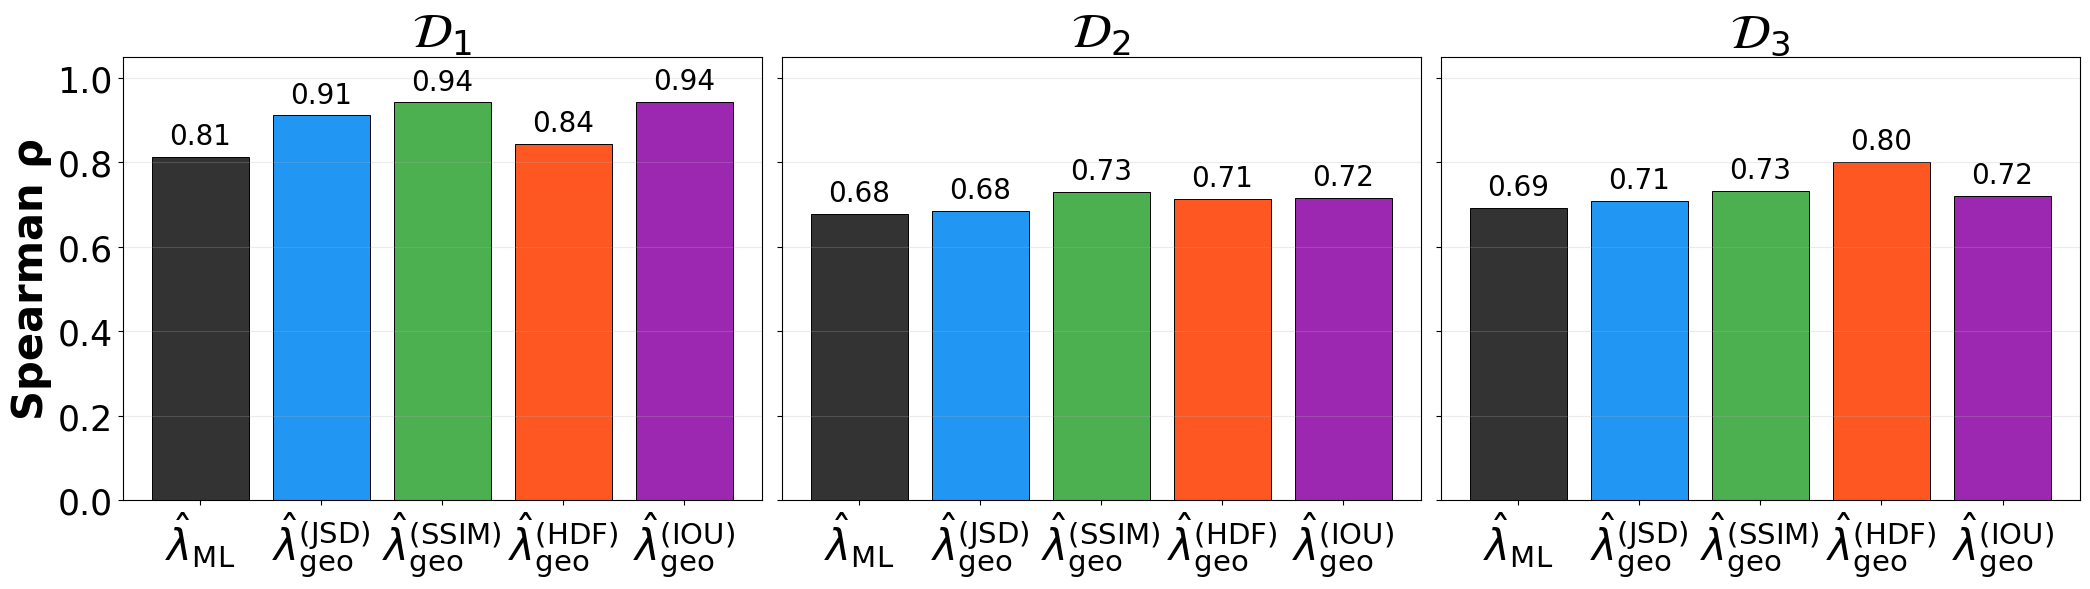

  Saved: d:\NLD_PROJECT\ML_FTLE\publication code\data\Fig_6.pdf


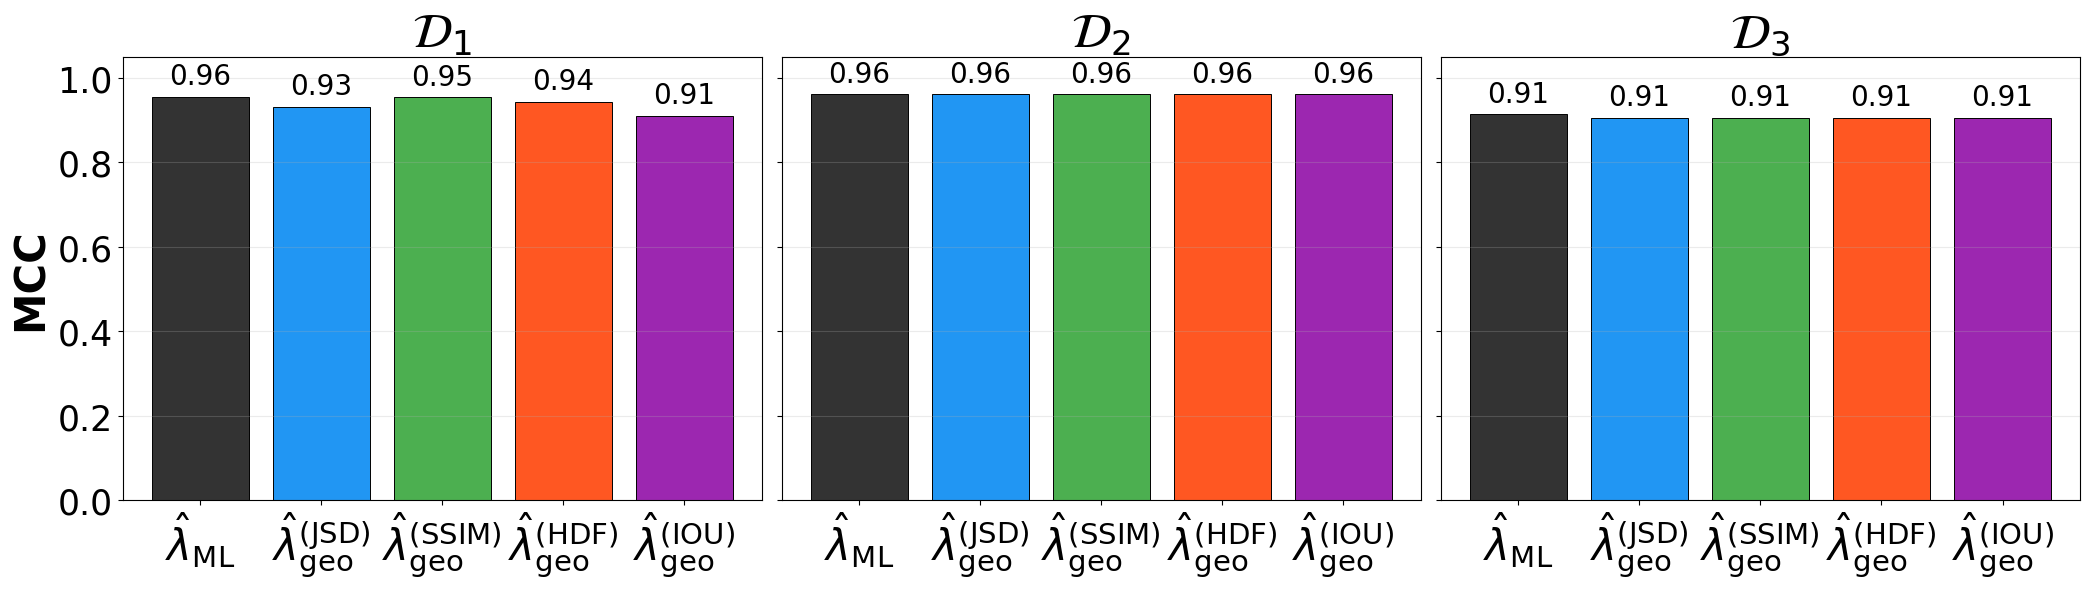

  Saved: d:\NLD_PROJECT\ML_FTLE\publication code\data\Fig_7.pdf


In [22]:
assert 'all_metrics' in globals() and all_metrics, \
    "Run the compute cell first — all_metrics is empty."
ds_names = list(all_metrics.keys())
n_ds     = len(ds_names)
_P0      = next(iter(PARAM_SETS.values()))
if n_ds == 0:
    raise RuntimeError("No datasets found in all_metrics.")
fig_w = max(7 * n_ds, 12)

def _plot_metric(metric_key, metric_label, ylim, ref_line, fname_stem):
    fig, axes = plt.subplots(1, n_ds, figsize=(fig_w, 6), sharey=True)
    if n_ds == 1:
        axes = [axes]
    for col_idx, ds_name in enumerate(ds_names):
        _P      = PARAM_SETS.get(ds_name, _P0)
        mdict   = all_metrics[ds_name]
        labels = list(mdict.keys())

        display_labels = {
            'ML-FTLE': r'$\hat{\lambda}_{\mathrm{ML}}$',
            'SSIM':    r'$\hat{\lambda}_{\mathrm{geo}}^{(\mathrm{SSIM})}$',
            'JSD':     r'$\hat{\lambda}_{\mathrm{geo}}^{(\mathrm{JSD})}$',
            'HDF':    r'$\hat{\lambda}_{\mathrm{geo}}^{(\mathrm{HDF})}$',
            'IOU':     r'$\hat{\lambda}_{\mathrm{geo}}^{(\mathrm{IOU})}$',
        }

        bcolors = [
            '#333333' if l == 'ML-FTLE'
            else _P.METHOD_COLORS.get(l, '#888')
            for l in labels
        ]
        xticklabels = [display_labels.get(l, l) for l in labels]
        x      = np.arange(len(labels))
        values = [mdict[l].get(metric_key, np.nan) for l in labels]
        ax     = axes[col_idx]
        bars   = ax.bar(x, values, color=bcolors, edgecolor='black', linewidth=0.7)
        for bar, v in zip(bars, values):
            if np.isfinite(v):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.015 * (ylim[1] - ylim[0]),
                    f'{v:.2f}',
                    ha='center', va='bottom', fontsize=20,
                )
        if ref_line is not None:
            ax.axhline(ref_line, color='gray', lw=0.9, ls='--')
        ax.axhline(0, color='black', lw=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(xticklabels, rotation=0, ha='center', fontsize=30, fontweight='bold')
        ax.set_ylim(*ylim)
        ax.tick_params(axis='y', labelsize=25)
        ax.set_title(rf'$\mathcal{{D}}_{{{col_idx+1}}}$', fontsize=35, fontweight='bold')
        ax.grid(True, alpha=_P0.GRID_ALPHA, axis='y')
        if col_idx == 0:
            ax.set_ylabel(metric_label, fontsize=30, fontweight='bold')
    """
    fig.suptitle(
        f'{metric_label} vs QR-FTLE — All Datasets',
        fontsize=14, fontweight='bold', y=1.02,
    )
    """
    plt.tight_layout()
    out_path = next(iter(DATASETS)).parent / f'{fname_stem}.pdf'
    plt.savefig(out_path, dpi=_P0.DPI_COMPOSITE, bbox_inches='tight')
    plt.show(); plt.close(fig)
    print(f'  Saved: {out_path}')

_plot_metric('spearman_rho', 'Spearman ρ', (0, 1.05), None,
             'Fig_6')
# ════════════════════════════════════════════════════════════════════════════
# PLOT  — MCC   (independent cell — run freely)
# ════════════════════════════════════════════════════════════════════════════
# (same preamble + _plot_metric definition as D1 — copy or import)
_plot_metric('mcc', 'MCC', (0, 1.05), None,
             'Fig_7')


### Summary dataframe

Builds a compact dataframe from `all_metrics` in which each row corresponds to one dataset-method pair and each column stores one evaluation metric.

This table is useful for manuscript verification because it makes it easy to check per-dataset rankings, recover the best-performing method under each metric, and confirm the numerical values reported in the bar plots.


In [23]:
rows = []
for ds, mdict in all_metrics.items():
    for method, m in mdict.items():
        rows.append({
            'dataset': ds,
            'signal': method,
            'spearman_rho': m.get('spearman_rho', np.nan),
            'mcc': m.get('mcc', np.nan),
            'sign_agree': m.get('sign_agree', np.nan),
            'n_valid': m.get('n_valid', np.nan),
        })
df_sum = pd.DataFrame(rows)

for ds, grp in df_sum.groupby('dataset'):
    valid = grp['spearman_rho'].dropna()
    if valid.empty:
        print(f'  {ds}: all NaN'); continue
    best = grp.loc[valid.idxmax()]
    print(f'  {ds:20s}  best: {best["signal"]:14s}'
          f'  ρ={best["spearman_rho"]:.3f}'
          f'  MCC={best["mcc"]:.3f}'
          f'  SA={best["sign_agree"]:.3f}')

  data_1                best: IOU             ρ=0.944  MCC=0.911  SA=0.612
  data_2                best: SSIM            ρ=0.731  MCC=0.961  SA=0.964
  data_3                best: HDF             ρ=0.802  MCC=0.906  SA=0.595
